Wir betrachten nun das Iris Datenset. Dieses hat folgend Eigenschaften:

* Je 50 Samples von drei verschiedenen Gattungen der Pflanze Iris
* 4 Features pro Sample: Länge und Breite von Kelchblatt (sepal) und Blütenblatt (petal) in cm

Sie können die Daten wie folgt laden:

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

# Load Iris dataset
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
target = iris.target
target_names = iris.target_names

Aufgabe 1) Visualisieren Sie mit paarweisen Scatterplots die Daten, d.h. plotten Sie für jede Kombination aus je 2 Features die Daten, plotten Sie dabei die Samples der drei Klassen in unterschiedlichen Farben. Verwenden Sie dazu am besten die Funktion pairplot aus Seaborn.

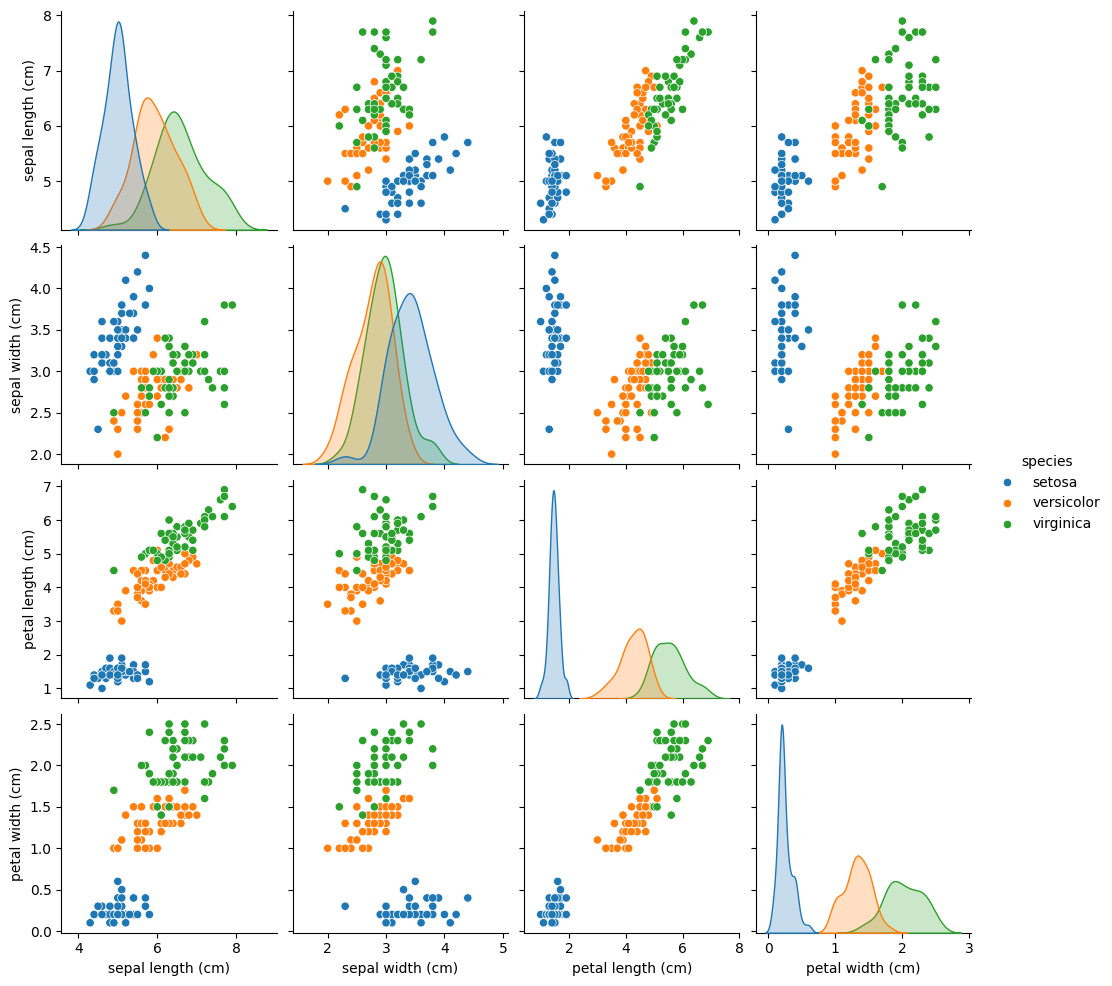

In [ ]:
# TODO
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(iris_df, hue='species')
plt.show()



Petal Length vs. Petal Width scheinen gut geeignet, um die Daten gemäß ihrer Klassenzugehörigkeit zu separieren. Wir beschränken die folgende Analyse daher auf diese beiden Features.

Nun prüfen wir, ob die Daten normalverteilt sind. Zunächst fitten wir eine multivariate Normalverteilung an alle (nun 2-dimensionalen) Datenpunkte:

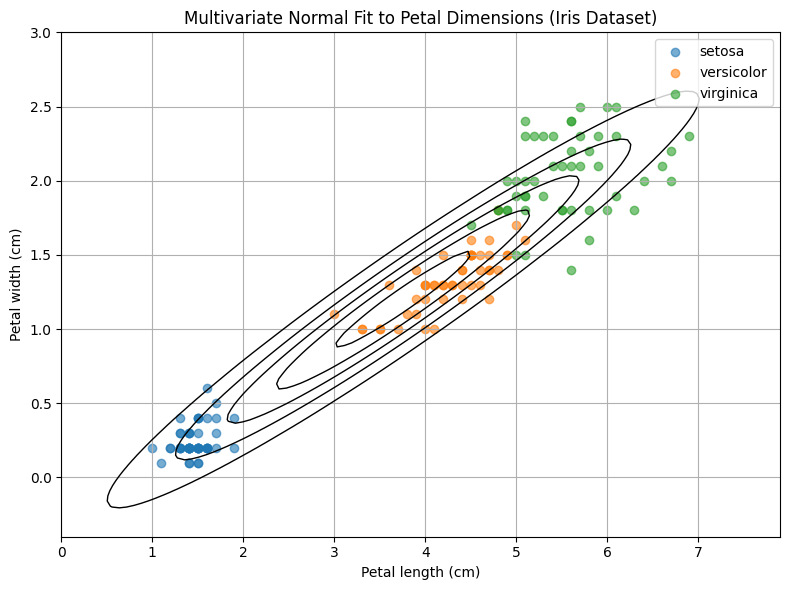

In [6]:
from scipy.stats import multivariate_normal

# Select petal length and width
X = iris_df[["petal length (cm)", "petal width (cm)"]].values

# Estimate mean and covariance
mu = np.mean(X, axis=0)
cov = np.cov(X, rowvar=False)

# Create a grid for plotting the density
x = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
y = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 100)
X_grid, Y_grid = np.meshgrid(x, y)
pos = np.dstack((X_grid, Y_grid))

# Evaluate the multivariate normal PDF
rv = multivariate_normal(mu, cov)
Z = rv.pdf(pos)

# Plotting
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
for i in range(3):
    plt.scatter(X[target == i, 0], X[target == i, 1], label=iris.target_names[i], alpha=0.6)

# Contour of the fitted Gaussian
plt.contour(X_grid, Y_grid, Z, levels=5, colors='black', linewidths=1)

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Multivariate Normal Fit to Petal Dimensions (Iris Dataset)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Aufgabe 2) Es scheint sinnvoller, je eine Normalverteilung pro Klasse zu verwenden. Adaptieren Sie den Code entsprechend!

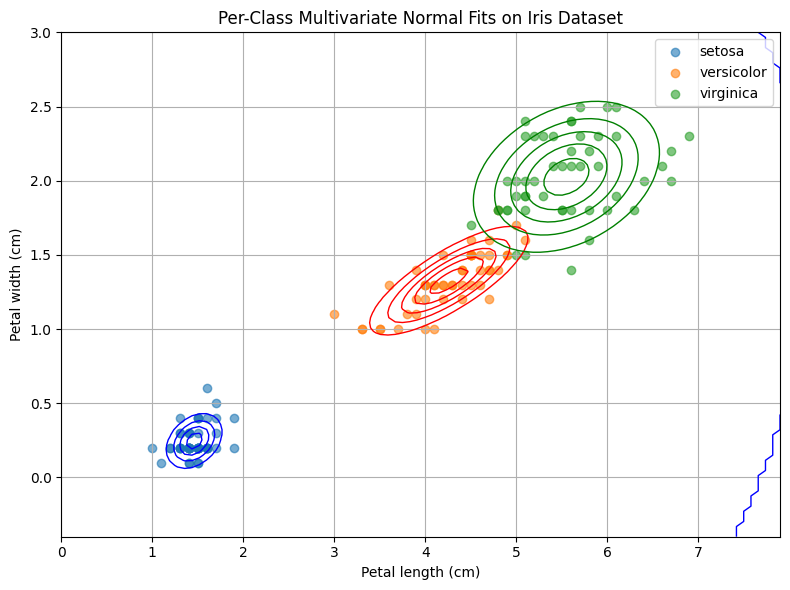

In [9]:
# Initialize plot
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']

# Fit and plot per-class multivariate normals
for i in range(3):
    class_data = X[target == i]

    # Scatter plot
    plt.scatter(class_data[:, 0], class_data[:, 1], label=iris.target_names[i], alpha=0.6)
    
    # Estimate mean and covariance
    mu = np.mean(class_data, axis=0)
    cov = np.cov(class_data, rowvar=False)

    # Evaluate the multivariate normal PDF
    rv = multivariate_normal(mu, cov)
    Z = rv.pdf(pos)

    plt.contour(X_grid, Y_grid, Z, levels=5, colors=colors[i-1], linewidths=1)

# Final plot settings
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Per-Class Multivariate Normal Fits on Iris Dataset")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Nun wollen wir wissen, ob die Daten - pro Klasse - tatsächlich normalverteilt sind. Dazu können wir verschiedene statistische Tests machen:

In [10]:
#!pip install pingouin

from pingouin import multivariate_normality
from scipy.stats import shapiro, normaltest

# Go over all species/classes
for i in range(3):
    print(f"Tests results for class {i} ({target_names[i]}): ")
    class_data = X[target == i]
    
    # Run Henze–Zirkler’s multivariate normality test
    hz_result = multivariate_normality(class_data, alpha=0.05)
    print(f"Henze-Zirkler's Test (Multivariate Normality): p={hz_result.pval:.4f}")
    
    # --- Univariate tests ---
    # Shapiro-Wilk
    shapiro_len = shapiro(class_data[:,0])
    shapiro_wid = shapiro(class_data[:,1])
    print("\nShapiro-Wilk:")
    print(f"  Petal length: p = {shapiro_len.pvalue:.4f}")
    print(f"  Petal width:  p = {shapiro_wid.pvalue:.4f}")
    
    # D’Agostino and Pearson
    dagostino_len = normaltest(class_data[:,0])
    dagostino_wid = normaltest(class_data[:,1])
    print("\nD’Agostino & Pearson:")
    print(f"  Petal length: p = {dagostino_len.pvalue:.4f}")
    print(f"  Petal width:  p = {dagostino_wid.pvalue:.4f}")
    print("\n")


Tests results for class 0 (setosa): 
Henze-Zirkler's Test (Multivariate Normality): p=0.0014

Shapiro-Wilk:
  Petal length: p = 0.0548
  Petal width:  p = 0.0000

D’Agostino & Pearson:
  Petal length: p = 0.3268
  Petal width:  p = 0.0006


Tests results for class 1 (versicolor): 
Henze-Zirkler's Test (Multivariate Normality): p=0.7486

Shapiro-Wilk:
  Petal length: p = 0.1585
  Petal width:  p = 0.0273

D’Agostino & Pearson:
  Petal length: p = 0.1903
  Petal width:  p = 0.8490


Tests results for class 2 (virginica): 
Henze-Zirkler's Test (Multivariate Normality): p=0.0261

Shapiro-Wilk:
  Petal length: p = 0.1098
  Petal width:  p = 0.0870

D’Agostino & Pearson:
  Petal length: p = 0.2593
  Petal width:  p = 0.5384




Was schließen Sie aus den Ergebnissen?

# TODO


Nun machen wir die Analyse noch einmal, dieses Mal auf allen Daten:

In [20]:
# now select all features and do a 4d analysis
X = iris_df[["petal length (cm)", "petal width (cm)", "sepal length (cm)", "sepal width (cm)"]].values
y = target

# Go over all species/classes
for i in range(3):
    print(f"Tests results for class {i} ({target_names[i]}): ")
    class_data = X[target == i]
    
    # Run Henze–Zirkler’s multivariate normality test
    hz_result = multivariate_normality(class_data, alpha=0.05)
    print(f"Henze-Zirkler's Test (Multivariate Normality): p={hz_result.pval:.4f}")
    
    print("\n")

Tests results for class 0 (setosa): 
Henze-Zirkler's Test (Multivariate Normality): p=0.0500


Tests results for class 1 (versicolor): 
Henze-Zirkler's Test (Multivariate Normality): p=0.2262


Tests results for class 2 (virginica): 
Henze-Zirkler's Test (Multivariate Normality): p=0.4970




Was gilt für die klassenweise Analyse der 4d-Daten? Sind sie normalverteilt?

# TODO


Aufgabe 3) Das bedeutet: Wir können eine LDA (Linear Discriminant Analysis) für die Klassifikation nutzen. Eine Implementierung hiervon findet sich in scikit-learn. Um die Generalisierungseigenschaft zu testen, splitten Sie die Daten bitte in ein Trainings- und ein Testset und bestimmen Sie die Klassifikationsgüte. Für das Splitten in Trainings- und Testset gibt es bereits vorgefertigte Methoden: 

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train/Test-Split (stratifiziert)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Data standardization
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# TODO



NameError: name 'X' is not defined